Feature Engineering on `areaWithType`, `additionalRoom`, `agePossession`, `furnishDetails` and `features` Columns

## Importing Libraries and Data

In [69]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import re

pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

In [70]:
df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_cleaned_v1.csv')
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,ashiana anmol,sohna road,0.9,9463.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet area: 951 sq.ft. (88.35 sq.m.),2,2,2,not available,13.0,South,1 to 5 Year Old,"['Global Signum Plaza', 'Airia Mall', 'Sohna Road', 'KR Mangalam University', 'GD Goenka School', 'GD Goenka University', 'Civil Hospital', 'Central Park', 'M2M football Club', 'Gurgaon Technology Valley', 'Lemon Tree Hotel', 'Sports academy and Gym', 'IndianOil']","['1 Water Purifier', '4 Fan', '1 Exhaust Fan', '2 Geyser', '1 Stove', '10 Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '1 Bed', '4 Wardrobe', '1 Sofa', '1 Washing Machine', 'No AC', 'No Dining Table', 'No Microwave', 'No Fridge', 'No TV']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Recently Renovated', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center', 'Water softening plant']"


## 1. areaWithType

- `Super Built up area`: Total saleable area, including the apartment’s carpet area plus proportionate share of common areas such as lobby, lift, staircase, clubhouse, and corridors.
- `Built Up area`: Carpet area plus the thickness of internal and external walls, and may include private balcony or terrace depending on builder convention.
- `Carpet area`: Net usable floor area inside the apartment where you can lay a carpet, excluding external walls, common areas, service shafts, and usually balconies/terraces.
- `Plot area`: The total area of the land on which the building is constructed, including the footprint of the building and any open spaces within the plot boundary.

`area` column is inconsistent and can contain any of the above area types.

areaWithType contains area with different units like sq.ft, sq.yds, sq.m, etc.

Creating three new columns - `superBuiltUpArea`, `builtUpArea` and `carpetArea`

In [71]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
3331,10.00,4072.0,Super Built up area 4072(378.3 sq.m.)Built Up area: 3000 sq.ft. (278.71 sq.m.)Carpet area: 2800 sq.ft. (260.13 sq.m.)
1859,1.09,1635.0,Super Built up area 1640(152.36 sq.m.)Built Up area: 1638 sq.ft. (152.18 sq.m.)Carpet area: 1635 sq.ft. (151.9 sq.m.)
1016,1.05,1400.0,Super Built up area 1875(174.19 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.)
842,1.15,1350.0,Carpet area: 1350 (125.42 sq.m.)
3559,0.54,750.0,Carpet area: 750 (69.68 sq.m.)


In [72]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [73]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [74]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [75]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [76]:
df[['carpet_area','areaWithType']].sample(10)

,carpet_area,areaWithType
647,1400.0,Super Built up area 1790(166.3 sq.m.)Built Up area: 1500 sq.ft. (139.35 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.)
1758,NaN,Plot area 900(83.61 sq.m.)
918,900.0,Super Built up area 1205(111.95 sq.m.)Carpet area: 900 sq.ft. (83.61 sq.m.)
3454,NaN,Super Built up area 2450(227.61 sq.m.)
2891,1685.0,Super Built up area 2408(223.71 sq.m.)Carpet area: 1685 sq.ft. (156.54 sq.m.)
2397,NaN,Super Built up area 1295(120.31 sq.m.)
3600,700.0,Carpet area: 700 (65.03 sq.m.)
1737,NaN,Super Built up area 1365(126.81 sq.m.)
589,2537.0,Carpet area: 2537 (235.7 sq.m.)
1342,NaN,Super Built up area 1930(179.3 sq.m.)


In [77]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2146,0.62,flat,523.0,Carpet area: 523 (48.59 sq.m.),NaN,NaN,523.0
3068,0.69,flat,1322.0,Super Built up area 1312(121.89 sq.m.)Built Up area: 1075 sq.ft. (99.87 sq.m.)Carpet area: 975 sq.ft. (90.58 sq.m.),1312.0,1075.0,975.0
3315,2.20,flat,1913.0,Super Built up area 1930(179.3 sq.m.),1930.0,NaN,NaN
3231,1.90,flat,1800.0,Carpet area: 1800 (167.23 sq.m.),NaN,NaN,1800.0
1999,8.44,flat,5200.0,Super Built up area 5200(483.1 sq.m.)Built Up area: 5000 sq.ft. (464.52 sq.m.)Carpet area: 4900 sq.ft. (455.22 sq.m.),5200.0,5000.0,4900.0


In [78]:
df.duplicated().sum()

np.int64(122)

In [79]:
df.drop_duplicates(inplace=True)

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
# Checking for rows where all three area columns are not null
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,3.20,flat,2625.0,Super Built up area 2625(243.87 sq.m.)Built Up area: 2600 sq.ft. (241.55 sq.m.)Carpet area: 2550 sq.ft. (236.9 sq.m.),2625.0,2600.0,2550.0
9,4.55,flat,4550.0,Super Built up area 4650(432 sq.m.)Built Up area: 4630 sq.ft. (430.14 sq.m.)Carpet area: 4550 sq.ft. (422.71 sq.m.),4650.0,4630.0,4550.0
14,1.20,flat,1760.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),1760.0,1186.0,1130.0
19,2.35,flat,1777.0,Super Built up area 1777(165.09 sq.m.)Built Up area: 1700 sq.ft. (157.94 sq.m.)Carpet area: 1600 sq.ft. (148.64 sq.m.),1777.0,1700.0,1600.0
22,1.90,flat,2250.0,Super Built up area 2727(253.35 sq.m.)Built Up area: 2500 sq.ft. (232.26 sq.m.)Carpet area: 2250 sq.ft. (209.03 sq.m.),2727.0,2500.0,2250.0


In [82]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(531, 7)

In [83]:
# Checking for rows where areaWithType contains 'Plot'
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,6.00,house,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 9000 sq.ft. (836.13 sq.m.),NaN,9000.0,NaN
8,16.00,house,4235.0,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
10,0.60,house,540.0,Plot area 60(50.17 sq.m.),NaN,NaN,NaN
23,1.16,house,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq.ft. (92.16 sq.m.),NaN,NaN,992.0
28,7.50,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN


In [84]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1048
agePossession             1
nearbyLocations         170
furnishDetails          946
features                599
super_built_up_area    1805
built_up_area          2534
carpet_area            1807
dtype: int64

In [85]:
# fetching rows where all three area columns are null
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
8,16.0,house,4235.0,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
10,0.6,house,540.0,Plot area 60(50.17 sq.m.),NaN,NaN,NaN
28,7.5,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
39,NaN,house,NaN,Plot area 520(434.79 sq.m.),NaN,NaN,NaN
41,2.1,house,900.0,Plot area 100(83.61 sq.m.),NaN,NaN,NaN


In [86]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [87]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [88]:
# filling plot area of houses into built_up_area column
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)
all_nan_df.shape

(545, 7)

In [89]:
# plot area in areaWithType column is not equal to area column as plot area is in yards
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3497,3.71,house,1872.0,Plot area 208(173.91 sq.m.),NaN,208.0,NaN
2149,0.75,house,1095.0,Plot area 1095(101.73 sq.m.),NaN,1095.0,NaN
303,0.40,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.0,NaN
857,18.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,502.0,NaN
2915,6.25,house,5400.0,Plot area 600(501.68 sq.m.),NaN,600.0,NaN


In [90]:
# converting plot area from yards and sq m to sqft
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [91]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)
all_nan_df.shape

(545, 7)

In [92]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
466,1.00,house,1215.0,Plot area 135(112.88 sq.m.),NaN,1215.0,NaN
2181,5.50,house,1935.0,Plot area 215(179.77 sq.m.),NaN,1935.0,NaN
917,4.60,house,1460.0,Plot area 1460(135.64 sq.m.),NaN,1460.0,NaN
1585,3.50,house,1080.0,Plot area 120(100.34 sq.m.),NaN,1080.0,NaN
3701,3.25,house,1512.0,Plot area 168(140.47 sq.m.),NaN,1512.0,NaN


In [93]:
# update the original dataframe
df.update(all_nan_df)

In [94]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1048
agePossession             1
nearbyLocations         170
furnishDetails          946
features                599
super_built_up_area    1805
built_up_area          1989
carpet_area            1807
dtype: int64

In [95]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
2788,house,ansal sushant lok plots,sector 43,7.00,25926.0,2700.0,Plot area 300(250.84 sq.m.),5,5,3+,"pooja room,study room,servant room",3.0,North-East,1 to 5 Year Old,"['Huda city centre metro station', 'New Life Church', 'Hanuman Mandir', 'Hdfc bank ATM', 'Standard chartered ATM', 'Hdfc ATM', 'Rbs ATM', 'Kotak mahindra bank ATM', 'Standard chartered ATM', 'Citi bank ATM', 'Icici ATM', 'Axis bank ATM', 'Hdfc ATM', 'Dr. Naval Mendiratta', 'Fortis Memorial Research Institute Fortis Vivekanand Hospital', 'Gupta', 'Dr. Kutbuddin Akbary', 'Max Hospital', 'Arihant Hospital', 'Paras Hospital Gurgaon', 'Sitaram Bhartia', 'Centre For Sight Gurgaon Sector 29', 'Guardian Pharmacy', 'Chikitsa', 'Gardian Pharmacy', 'City Medical', 'Bharat petroleum', 'Icici bank', 'Hdfc bank', 'Axis bank', 'PWO house', 'Balaji Vegetarian Paradise', 'The Chicken Boat', 'Naveidyam', 'CCD', 'Drunken Monkey', 'Belgian Waffle', 'Starbucks', 'Blue Tokai Coffee Roasters', 'Dighent cafe', 'Pizza Hut', 'Fat', 'Nowhere Brewpub and cafe', 'Stones2milestones', 'School of Inspired Leadership SOIL', 'Ncr library', 'Bahrisons library']","['20 Wardrobe', '11 Fan', '1 Exhaust Fan', '7 Geyser', '1 Stove', '32 Light', '11 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']",NaN,2700.0,NaN
771,flat,pivotal riddhi siddhi,sector 99,0.40,4444.0,900.0,Super Built up area 900(83.61 sq.m.)Carpet area: 587 sq.ft. (54.53 sq.m.),2,2,2,not available,9.0,NaN,0 to 1 Year Old,"['Huda Metro Station', 'The Hive Mall', 'JMS Marine Square Mall', 'Dwarka Expy, Sector 101', 'Euro International School, Sector 37D', 'Rishikul College Gurugram', 'Shri Balaji’s Multispeciality', 'Indira Gandhi Intl Airport']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Security Personnel', 'Shopping Centre', 'Club house / Community Center']",900.0,NaN,587.0
697,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,not available,4.0,NaN,undefined,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump', 'HP Petrol Pump', 'Indian Oil', 'Essar Petrol Pump', 'Garhi harsaru junction railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1743.0,NaN
2186,house,independent,sector 2,0.70,7777.0,900.0,Built Up area: 900 (83.61 sq.m.),1,1,0,not available,1.0,NaN,undefined,"['Palam triangle', 'HUDA Sector 23 Market', 'Palam Vihar Vyapar kendra', 'Ram Mandir', 'Sheetla Mata Mandir', 'State bank of india ATM', 'Hdfc bank ATM', 'Hsbc bank ATM', ""DR KAPOOR'S Dental Care and Implant Centre"", 'Kalyan Hospital Gurgaon', 'Metro Hospital and Heart Institute Gurgaon', 'Apollo Cradle Hospital Gurgaon', 'Kishor Clinic', 'Jeevan Jyoti Hospital Gurgaon', 'Sheetla Clinic', ""Dr. Anurag's Child Care Clinic"", 'Children Hospital', 'Yashroop Medical Centre', 'Jiya Clinic', 'Dr. Tomar Clinic', 'Dr. Mittal Clinic', 'Dr. Babita Sharma', 'Ansals Plaza above ground car parking', 'Ansals plaza underground car parking', 'HUDA sector 23 parking', 'Punjab national bank', 'Axis bank', 'Oriental bank of commerce', 'Catholic syrian bank', 'Karur vysay bank', 'Oriental bank of commerce', 'Hdfc bank', 'Icici bank', 'Big Cinemas', ""McDonald's"", 'Moti Ma

## 2.additionalRoom

- `study room` : A room in a house used for reading, writing, or academic work.
- `store room` : A room in a house used for storing items.
- `pooja room` : A room in a house used for religious or spiritual activities.
- `servant room` : A room in a house used for the accommodation of servants.
- `others` : Any other type of room not covered by the above categories.

there are to many combination of these rooms so will divide into 5 columns like one-hot encoding

In [96]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1516
servant room                                      688
study room                                        243
others                                            219
pooja room                                        164
                                                 ... 
servant room,study room,store room,pooja room       1
others,study room                                   1
store room,study room                               1
servant room,store room,study room,pooja room       1
pooja room,store room,servant room                  1
Name: count, Length: 65, dtype: int64

In [97]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [98]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
427,not available,0,0,0,0,0
704,servant room,0,1,0,0,0
488,"pooja room,study room",1,0,0,1,0
2234,pooja room,0,0,0,1,0
1509,not available,0,0,0,0,0


## 3.agePossession

In [99]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1646
5 to 10 Year Old       563
0 to 1 Year Old        503
undefined              307
10+ Year Old           303
Under Construction      88
Within 6 months         67
Within 3 months         24
Dec 2023                20
By 2023                 17
By 2024                 16
Dec 2024                15
Mar 2024                12
Jun 2024                 7
Dec 2025                 7
Jan 2024                 7
Oct 2024                 6
Aug 2023                 6
Nov 2023                 5
Aug 2024                 4
By 2025                  4
Sep 2023                 4
Oct 2023                 4
May 2024                 3
Jan 2025                 3
Feb 2024                 3
Nov 2024                 3
Jul 2024                 3
Jan 2026                 2
By 2027                  2
Jul 2025                 2
Apr 2026                 2
Jun 2027                 2
Jul 2027                 2
Mar 2025                 2
Dec 2026                 2
Aug 2025      

In [100]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [101]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [102]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           594
Moderately Old         563
Undefined              308
Old Property           303
Under Construction     267
Name: count, dtype: int64

## 4.furnishDetails

furnishDetails column contains 18 unique values which can be split into 18 news columns but i categorized into 4 categories - `furnished`, `semi-furnished`, `unfurnished` and `others`.

In [103]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3080,NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
2639,"['3 Fan', '1 Exhaust Fan', '3 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Park', 'Visitor Parking']"
2303,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
197,NaN,"['Power Back-up', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Water Storage', 'Park', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
3732,NaN,"['Private Garden / Terrace', 'Lift(s)', 'Maintenance Staff', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Swimming Pool', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"


In [104]:
# Extract all unique furnishings from the furnishDetails column and converting into 18 new columns
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]
furnishings_df.shape

(3681, 19)

In [105]:
furnishings_df.drop(columns=['furnishDetails'], inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13060\466072287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'], inplace=True)


In [106]:
furnishings_df.sample(5)

,Exhaust Fan,Light,Microwave,Fan,Stove,Geyser,Curtains,Bed,Wardrobe,TV,AC,Washing Machine,Dining Table,Modular Kitchen,Fridge,Water Purifier,Sofa,Chimney
1978,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2637,0,1,1,1,0,3,0,0,0,0,1,0,0,0,0,0,0,1
2089,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1869,1,10,0,7,0,2,6,0,4,0,2,0,0,1,0,0,0,1
2455,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


Clustering the group the similar columns together

In [107]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

Elbow method show that 3 clusters are optimal for our data.

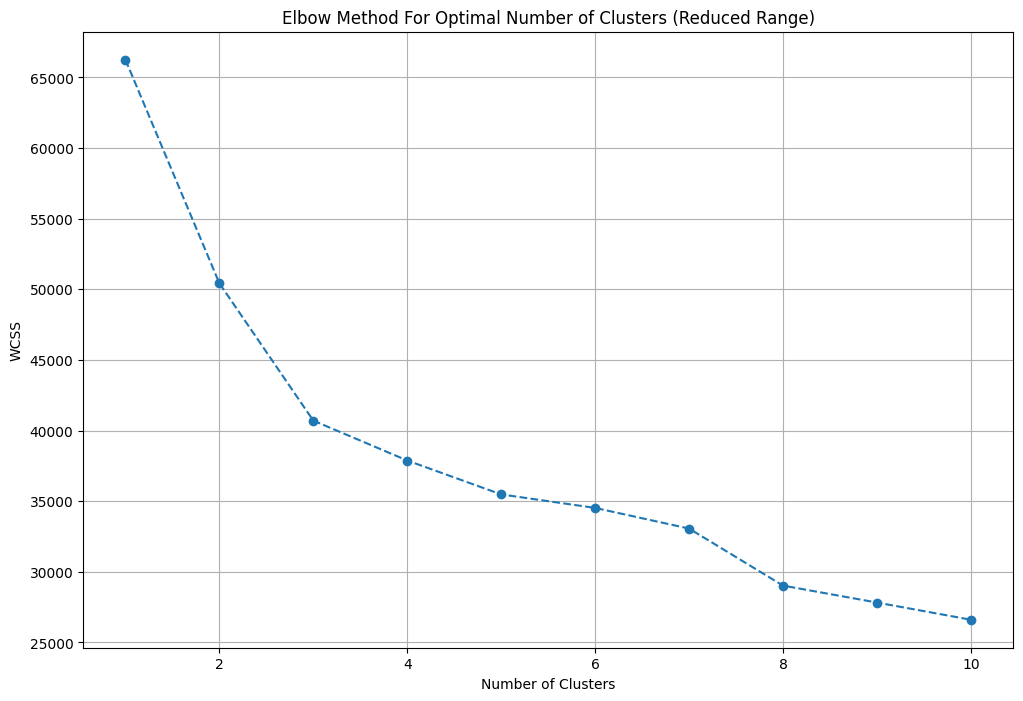

In [108]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [109]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [110]:
df = df.iloc[:,:-18]

In [111]:
df['furnishing_type'] = cluster_assignments

- 0 : unfurnished
- 1 : semifurnished
- 2 : furnished

In [112]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
1176,NaN,0
850,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3268,"['5 Fan', '6 Light', '5 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
2597,[],0
2499,"['4 Fan', '4 Geyser', '5 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0


## 5.features

In [113]:
df[['society','features']].sample(5)

,society,features
2437,paras dews,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
2134,dlf city plots phase 2,"['Security / Fire Alarm', 'Private Garden / Terrace', 'High Ceiling Height', 'Separate entry for servant room', 'Park', 'Bank Attached Property', 'Visitor Parking', 'Security Personnel', 'Airy Rooms', 'Low Density Society']"
1977,ashiana mulberry,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Visitor Parking', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1730,satya the hermitage,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
173,m3m soulitude,"['Intercom Facility', 'Lift(s)', 'Piped-gas', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [114]:
df['features'].isnull().sum()

np.int64(599)

To fill Null values in the features column, we used apartment database and map with society column with PropertyName column.

In [115]:
app_df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/Data Gathering/Apartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [116]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [117]:
temp_df = df[df['features'].isnull()]
temp_df.shape

(599, 26)

In [118]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [119]:
df.loc[temp_df.index,'features'] = x.values

Null values reduced from 635 to 481

In [120]:
df['features'].isnull().sum()

np.int64(457)

There are total 154 unique features in the features column so we can create 154 new columns with one-hot encoding or we can cluster into categories.

In [121]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)
features_binary_df.shape

(3681, 130)

In [122]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,...,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2921,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2132,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
656,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [123]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10 ,random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

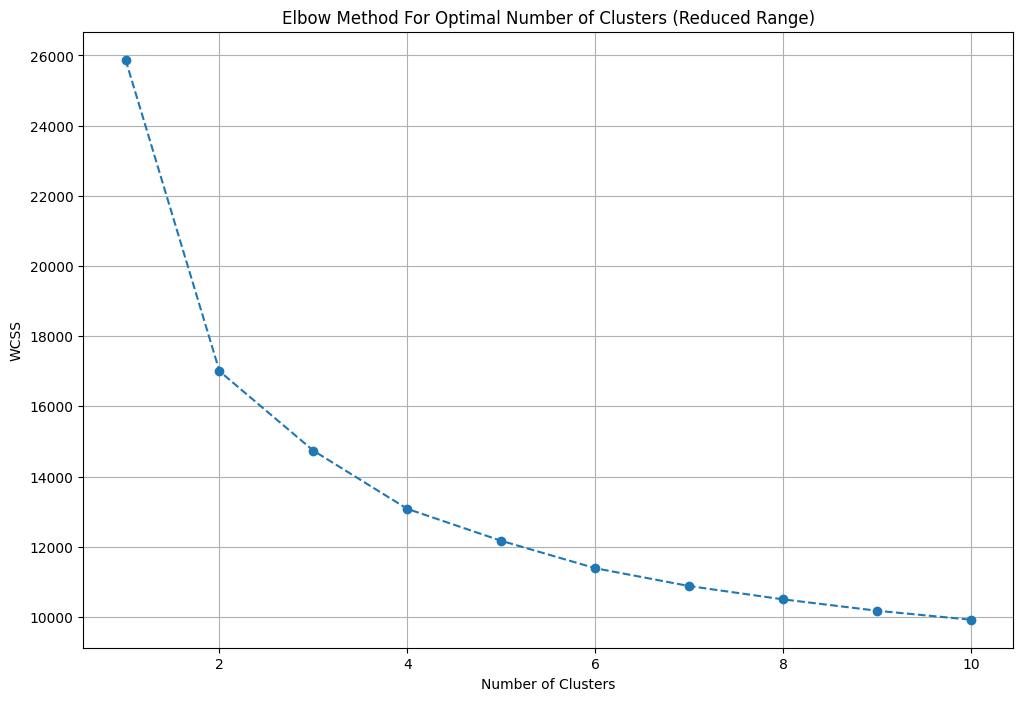

In [124]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

It is giving two clusters one with Nan and rest to other category. It is not good. so try other way.

Define the weights for each feature as provided by assigning weights based on perceived luxury contribution.

In [125]:
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)
df['luxury_score'] = luxury_score
df.shape


(3681, 28)

In [126]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
1460,flat,satya element one,sector 49,0.80,11111.0,720.0,Built Up area: 720 (66.89 sq.m.),1,1,1,...,720.00,NaN,0,0,0,0,0,0,[],49.0
2853,flat,experion windchants,sector 112,5.31,11204.0,4739.0,Super Built up area 4739(440.27 sq.m.)Built Up area: 3573.33 sq.ft. (331.97 sq.m.)Carpet area: 3400 sq.ft. (315.87 sq.m.),4,6,3+,...,3573.33,3400.0,0,1,0,1,0,0,"[Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Maintenance Staff, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Shopping Centre, Fitness Centre / GYM, Rain Water Harvesting, Club house / Community Center, Water softening plant]",120.0
2966,house,4s aradhya homes,sector 67a,1.83,6778.0,2700.0,Plot area 300(250.84 sq.m.),4,4,2,...,2700.00,NaN,0,0,0,1,0,2,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Centrally Air Conditioned, High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, No open drainage around, Recently Renovated, Piped-gas, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Internet/wi-fi connectivity, Airy Rooms, Spacious Interiors, Low Density Society, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center]",156.0
147,flat,suncity vatsal valley,gwal pahari,1.38,12212.0,1130.0,Built Up area: 1130 (104.98 sq.m.),2,2,2,...,1130.00,NaN,0,0,0,0,0,0,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Intercom Facility, Lift(s), Maintenance Staff, False Ceiling Lighting, Water Storage, No open drainage around, Piped-gas, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Internet/wi-fi connectivity, Airy Rooms, Low Density Society, Shopping Centre, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center]",133.0
880,flat,ireo the corridors,sector 67a,1.70,9843.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet area: 1017 sq.ft. (94.48 sq.m.),3,3,2,...,NaN,1017.0,0,1,0,0,1,2,"[Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",16.0


## Conclusion

Droping non usefull columns `nearbyLocations`, `furnishDetails`, `features`, `features_list`, `additionalRoom`

In [127]:
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'], inplace=True)
df.shape

(3681, 23)

In [128]:
df.to_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_cleaned_v2.csv', index=False)